In [80]:
import tensorflow as tf
import pandas as pd
from sklearn import preprocessing 

import matplotlib.pyplot as pt

In [81]:
X_train = pd.read_csv(
    "E:/nvbn/Nural_network/Neural_network/database/Arabic Handwritten Digits Dataset CSV/csvTrainImages 60k x 784.csv"
)
y_train = pd.read_csv(
    "E:/nvbn/Nural_network/Neural_network/database/Arabic Handwritten Digits Dataset CSV/csvTrainLabel 60k x 1.csv"
)

X_test = pd.read_csv(
    "E:/nvbn/Nural_network/Neural_network/database/Arabic Handwritten Digits Dataset CSV/csvTestImages 10k x 784.csv"
)
y_test = pd.read_csv(
    "E:/nvbn/Nural_network/Neural_network/database/Arabic Handwritten Digits Dataset CSV/csvTestLabel 10k x 1.csv"
)

In [82]:
print(f"X_train shape = {X_train.shape}")
print(f"y_train shape = {y_train.shape}")

print(f"X_test shape = {X_test.shape}")
print(f"y_test shape = {y_test.shape}")

X_train shape = (59999, 784)
y_train shape = (59999, 1)
X_test shape = (9999, 784)
y_test shape = (9999, 1)


In [83]:

X_train = X_train.values.reshape(-1,28,28)
X_test =X_test.values.reshape(-1,28,28)


Text(0.5, 1.0, '[3]')

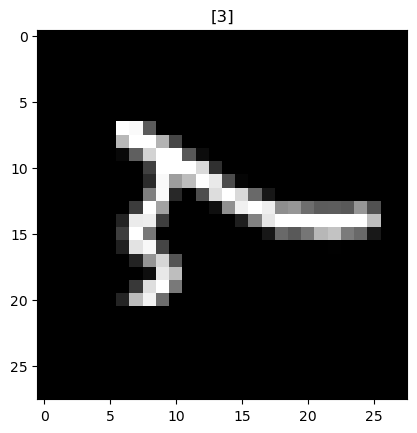

In [84]:
i = 2
pt.imshow(X_train[i : i + 1].reshape(-1, 28, 28)[0], cmap="gray")
pt.title(y_train[i : i + 1].values[0])

In [85]:
model = tf.keras.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(100, activation="relu", input_dim=64),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(150, activation="relu", input_dim=64),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(110, activation="relu", input_dim=64),
        tf.keras.layers.Dense(10),
    ]
)

c:\Users\r.navabian\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\r.navabian\AppData\Local\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits= True),
    metrics=["accuracy"],
)

In [87]:
# model.summary()

In [88]:
model.fit(X_train, y_train, epochs=10,validation_split= 0.2 )

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.3260 - loss: 4.7997 - val_accuracy: 0.6254 - val_loss: 1.0848
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5155 - loss: 1.4200 - val_accuracy: 0.7776 - val_loss: 0.6852
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6270 - loss: 1.1181 - val_accuracy: 0.8168 - val_loss: 0.5800
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7012 - loss: 0.8932 - val_accuracy: 0.8455 - val_loss: 0.4859
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7313 - loss: 0.7875 - val_accuracy: 0.8523 - val_loss: 0.4618
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7545 - loss: 0.7052 - val_accuracy: 0.8570 - val_loss: 0.4390
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7787 - loss: 0.6444 - val_accuracy: 0.8611 - val_loss: 0.4181
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7906 - loss: 0.6042 - 

In [89]:
model.history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

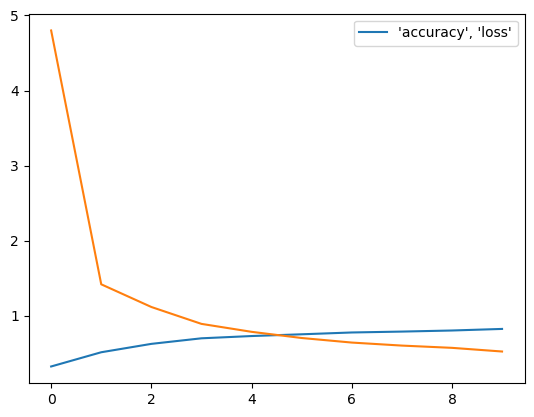

In [90]:
pt.plot(model.history.history["accuracy"])
pt.plot(model.history.history["loss"])
pt.legend(["'accuracy', 'loss'"])

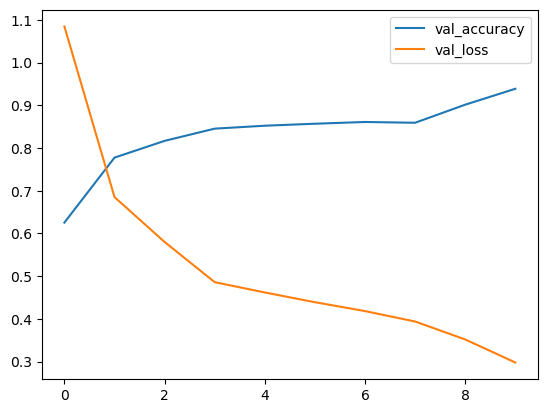

In [91]:
pt.plot(model.history.history["val_accuracy"])
pt.plot(model.history.history["val_loss"])
pt.legend(["val_accuracy", "val_loss"])

In [92]:
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9300 - loss: 0.3081


[0.308052122592926, 0.9299929738044739]

Text(0.5, 1.0, '[6]')

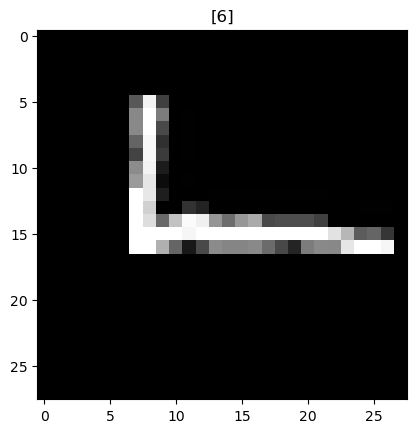

In [97]:
i = 35
pt.imshow(X_test[i : i + 1].reshape(-1, 28, 28)[0], cmap="gray")
pt.title(y_test[i : i + 1].values[0])